In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None);

In [64]:
# Load the data
df = pd.read_csv("../data/churn.csv")

# Drop the columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])


df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [65]:
# The size of the dataset
df.shape

(10000, 11)

In [66]:
# Feature information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [67]:
# Descriptive statistics of the data set
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [68]:
# Missing values
missing = df.isnull().sum()
missing

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [73]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['Geography', 'Gender']


In [76]:
# Numeric Variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", num_cols)


Numeric columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [79]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print("Binary columns:", binary_cols)

Binary columns: ['Gender', 'HasCrCard', 'IsActiveMember', 'Exited']


array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>],
       [<Axes: title={'center': 'IsActiveMember'}>,
        <Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>]], dtype=object)

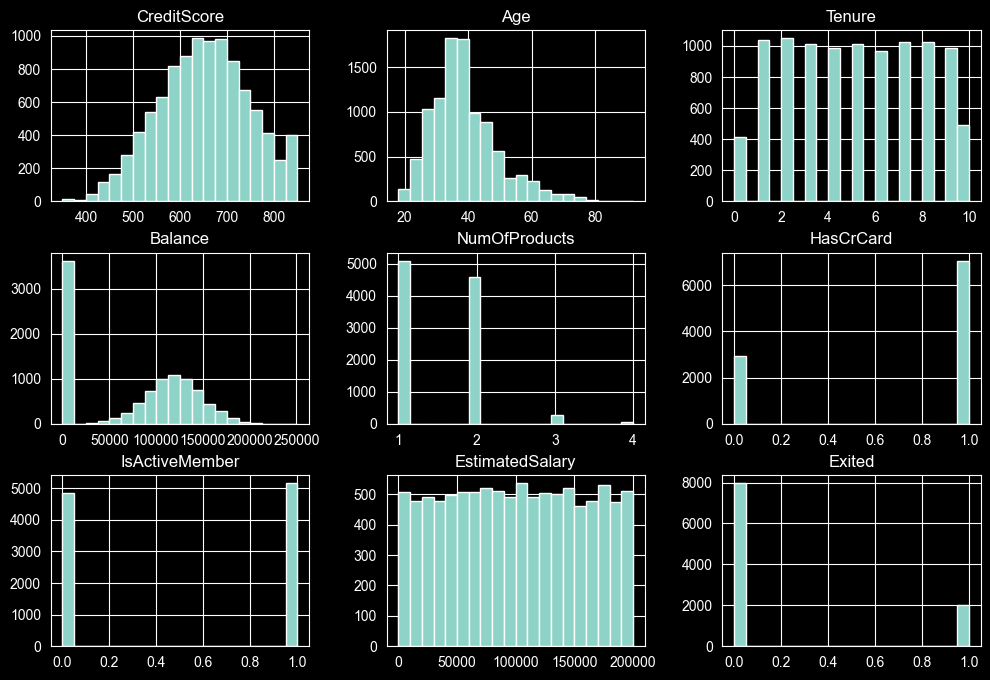

In [80]:
df[num_cols].hist(bins=20, figsize=(12,8))

In [81]:
df["Exited"].value_counts(normalize=True) # Imbalanced dataset

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

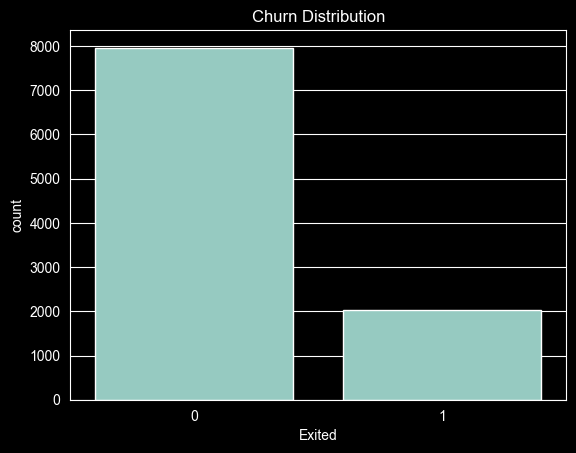

In [82]:
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution')
plt.show()

In [30]:
for col in cat_cols[1:]:
    print(df[col].value_counts())
    print("--------------")


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
--------------
Gender
Male      5457
Female    4543
Name: count, dtype: int64
--------------


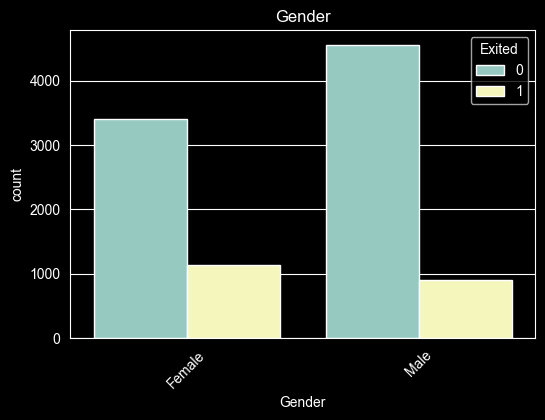

In [84]:
for col in cat_cols[1:]:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Exited', data=df)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [85]:
df[num_cols].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


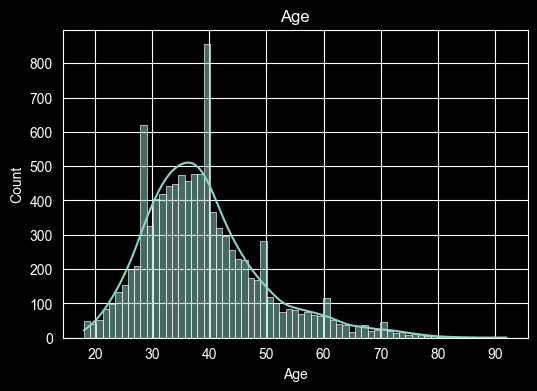

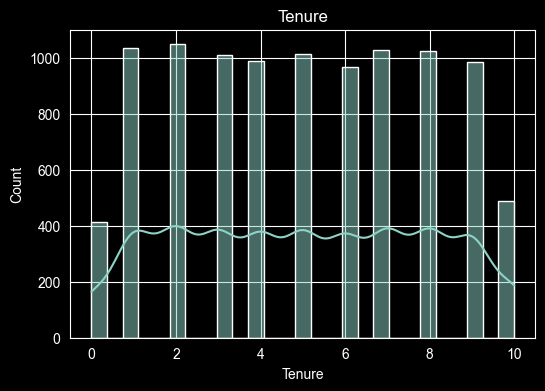

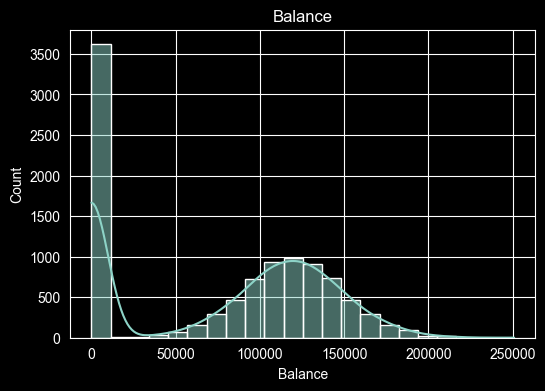

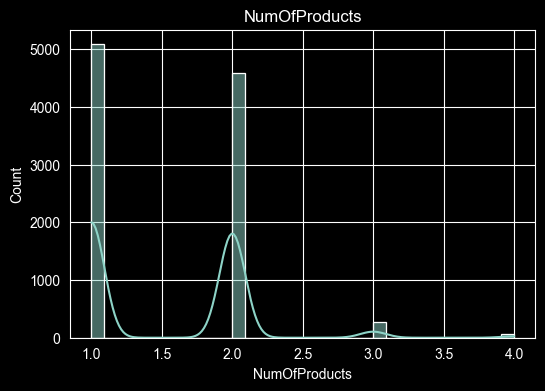

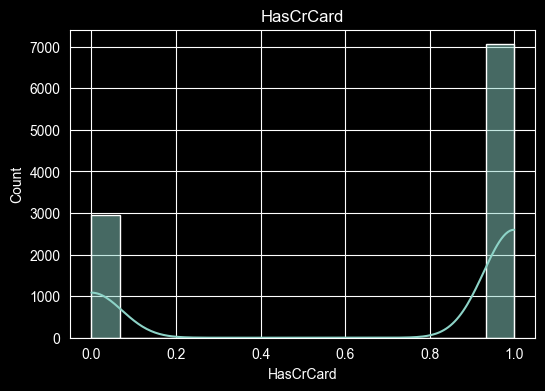

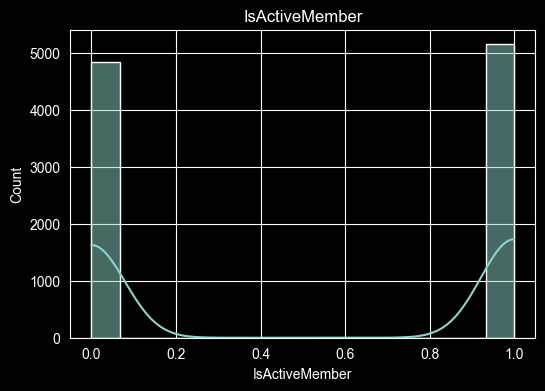

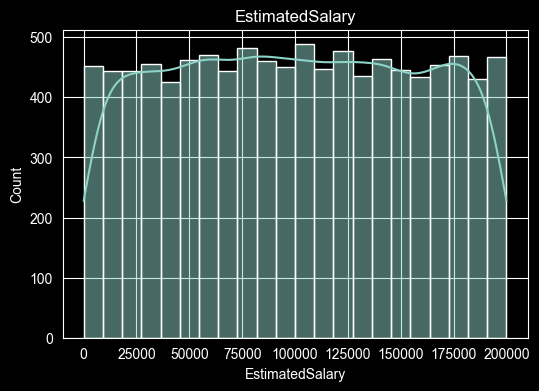

In [86]:
for col in num_cols[1:-1]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

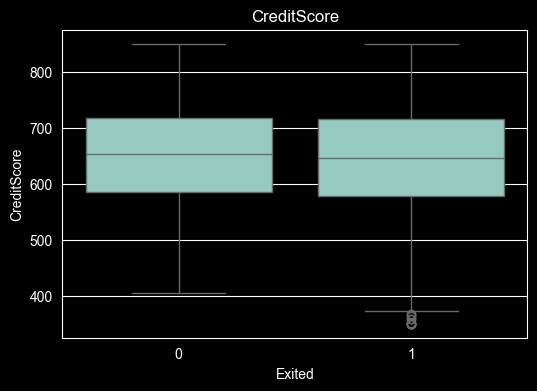

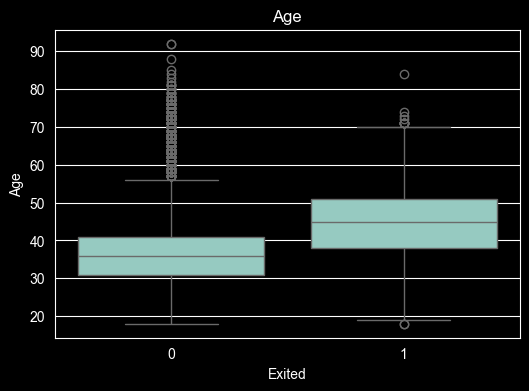

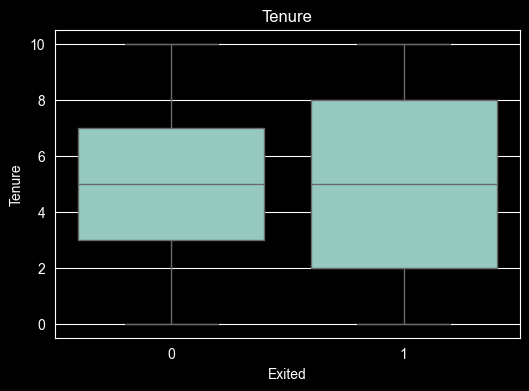

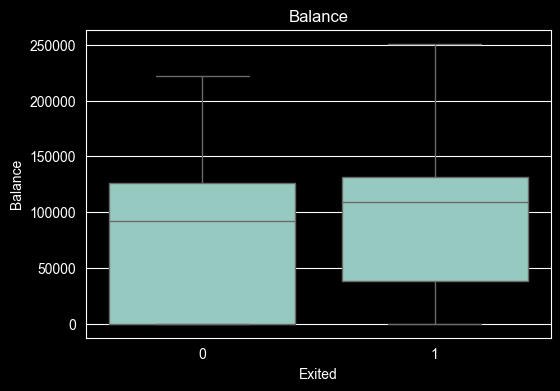

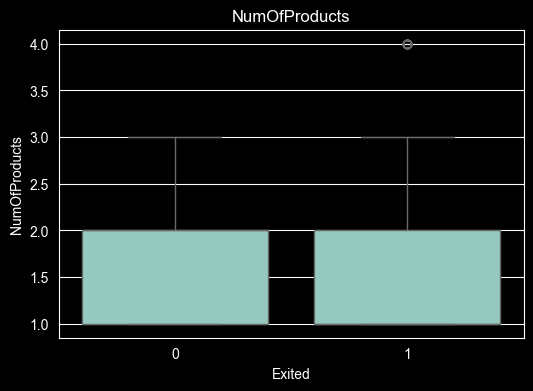

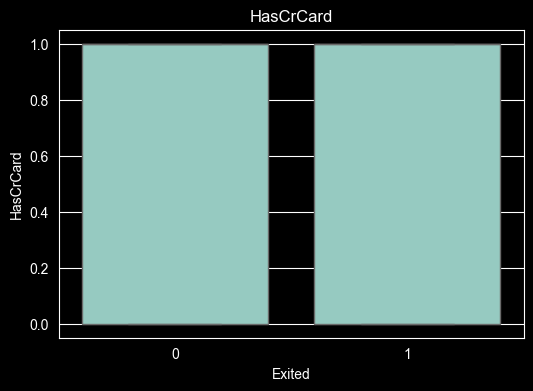

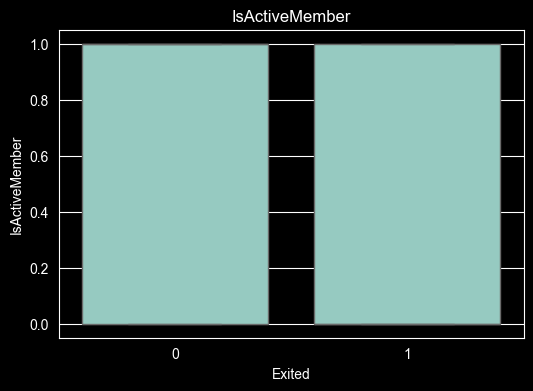

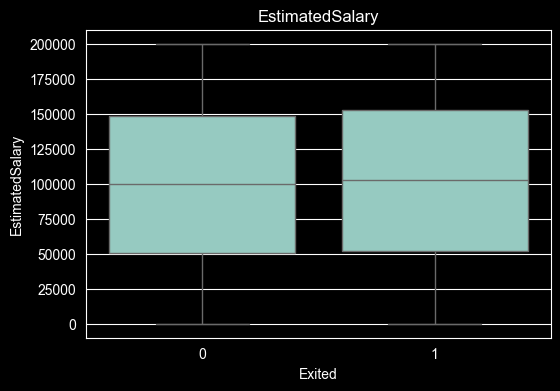

In [36]:
for col in num_cols[1:-1]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(col)
    plt.show()

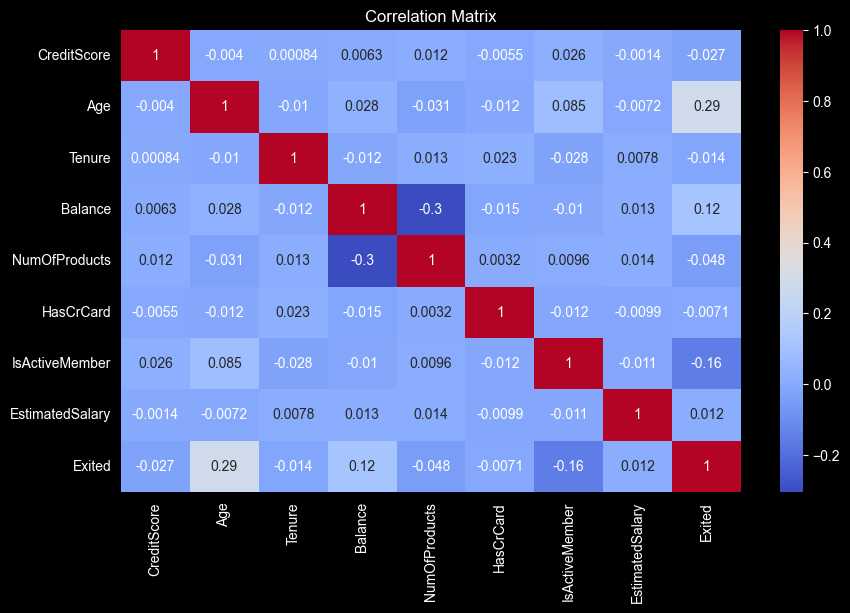

In [39]:
corr = df[num_cols[1:-1] + ['Exited']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


<Axes: xlabel='EstimatedSalary'>

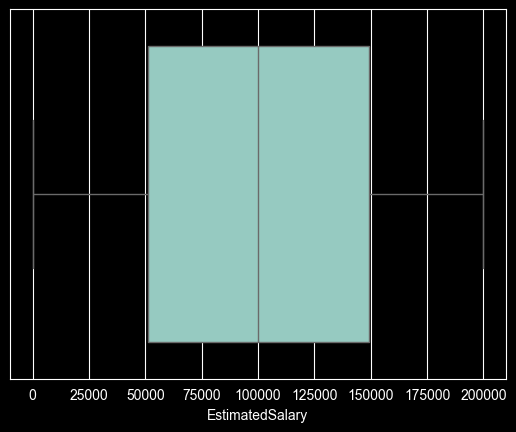

In [88]:
sns.boxplot(x=df["EstimatedSalary"])

Conclusions

1. Customers in Germany have the highest churn rate.
2. Older customers churn more frequently.
3. Inactive members are much more likely to leave.
4. Customers with higher balances show higher churn probability.
5. Dataset has moderate class imbalance (~20% churn).
6. Most customers are between 30–45 years old.
7. Female customers churn slightly more than males.
8. Many customers have zero balance accounts.
9. Age ↗ → churn probability increases
10. IsActiveMember ↘ → churn decreases


Important variables

Age
Geography
IsActiveMember
Balance
NumOfProducts

Inactive custumers are much more likely to churn.

In [89]:
df["Balance"]

0            0.00
1        83807.86
2       159660.80
3            0.00
4       125510.82
5       113755.78
6            0.00
7       115046.74
8       142051.07
9       134603.88
10      102016.72
11           0.00
12           0.00
13           0.00
14           0.00
15      143129.41
16      132602.88
17           0.00
18           0.00
19           0.00
20           0.00
21           0.00
22           0.00
23           0.00
24           0.00
25           0.00
26      136815.64
27           0.00
28      141349.43
29       59697.17
30           0.00
31       85311.70
32      110112.54
33           0.00
34           0.00
35      134264.04
36      145260.23
37       76548.60
38           0.00
39       70349.48
40           0.00
41      122522.32
42      117419.35
43      131394.56
44      155931.11
45      109421.13
46      112045.67
47      137843.80
48      103391.38
49      103769.22
50      116363.37
51      146050.97
52           0.00
53      125561.97
54       98495.72
55      12